# Etapas 2 e 3: Limpeza e Análise Exploratória (EDA)

Objetivos de Aprendizagem 3 e 4: limpar e tratar os dados (ausentes, outliers, conversão de tipos) e explorá-los (estatísticas descritivas, distribuições, correlações).

| Tarefa obrigatória (Etapa 2) | Seção |
|---|---|
| 1. `"R$ 1.200.000"` → `1200000.0` | Texto → número |
| 2. `"75 m²"` → `75.0` | Texto → número |
| 3. Tratar valores ausentes (`dropna` ou imputação) | Ausentes e duplicados |
| 4. Remover outliers evidentes (preço > 3× IQR) | Outliers |
| 5. Criar `preco_m2 = preco / area_m2` para análise | Outliers |

Entrada: `imoveis_brutos.csv`. Saída: `imoveis_limpos.csv` e os gráficos em `figs/`, que vão para o relatório.

## Imports

In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

os.makedirs("figs", exist_ok=True)                    # pasta dos gráficos do relatório
bruto = pd.read_csv("imoveis_brutos.csv", dtype=str)
print(f"Brutos carregados: {bruto.shape[0]} linhas x {bruto.shape[1]} colunas")

Brutos carregados: 299 linhas x 14 colunas


## Texto → número (tarefas 1 e 2)

O scraping entrega texto. Para a regressão, cada coluna precisa virar `float`.

- **Faixas** como `"2 - 3"` banheiros (unidades com variações) ficam com o **menor** número, uma escolha conservadora.
- **Lançamentos** (`"A partir de R$ ..."`) saem, porque o valor é o da unidade mais barata do empreendimento, não o preço de um imóvel.

In [ ]:
def limpar_preco(valor):
    """'R$ 1.200.000' -> 1200000.0; sem dígitos ('Sob consulta') -> NaN."""
    if pd.isna(valor):
        return np.nan
    so_digitos = re.sub(r"[^\d]", "", str(valor))
    return float(so_digitos) if so_digitos else np.nan


def primeiro_numero(valor):
    """'75 m²' -> 75.0 | '2 - 3' -> 2.0 | '1.200 m²' -> 1200.0 | vazio -> NaN."""
    if pd.isna(valor):
        return np.nan
    achado = re.search(r"\d+", str(valor).replace(".", ""))   # tira o ponto de milhar antes
    return float(achado.group()) if achado else np.nan


print("--- Teste das funções ---")
print(limpar_preco("R$ 1.200.000"), primeiro_numero("75 m²"), primeiro_numero("2 - 3"), "\n")

df = bruto.copy()
df = df[~df["preco"].str.contains("A partir", na=False)]   # lançamentos
print(f"Lançamentos removidos: {len(bruto) - len(df)}\n")

df["preco"] = df["preco"].apply(limpar_preco)              
for coluna in ["area_m2", "quartos", "banheiros", "vagas"]:
    df[coluna] = df[coluna].apply(primeiro_numero)

print("--- Tipos após a conversão ---")
df.info()

--- Teste das funções ---
1200000.0 75.0 2.0 

Lançamentos removidos: 3

--- Tipos após a conversão ---
<class 'pandas.DataFrame'>
Index: 296 entries, 0 to 298
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           296 non-null    str    
 1   preco        296 non-null    float64
 2   area_m2      296 non-null    float64
 3   quartos      294 non-null    float64
 4   banheiros    295 non-null    float64
 5   vagas        241 non-null    float64
 6   bairro       296 non-null    str    
 7   tipo         296 non-null    str    
 8   condominio   296 non-null    str    
 9   iptu         296 non-null    str    
 10  endereco     296 non-null    str    
 11  titulo       296 non-null    str    
 12  link         296 non-null    str    
 13  coletado_em  296 non-null    str    
dtypes: float64(5), str(9)
memory usage: 34.7 KB


## Ausentes e duplicados (tarefa 3)

As duas estratégias do PDF, cada uma onde faz sentido:

- **Imputação:** `vagas` vazia vira **0**. O anúncio omite o campo quando não há vaga, e muito prédio antigo das superquadras não tem vaga privativa. A média ("1,7 vaga") não existiria no mundo real.
- **`dropna`:** sem preço, área, quartos ou banheiros, a linha sai. São as variáveis do modelo, e imputar o próprio alvo seria inventar dado.

Também saem os **duplicados**: o mesmo imóvel anunciado por imobiliárias diferentes tem as mesmas características, mas `id` diferente.

In [ ]:
print("--- Ausentes ANTES ---")
print(df.isna().sum(), "\n")

antes = len(df)
df["vagas"] = df["vagas"].fillna(0)
df = df.dropna(subset=["preco", "area_m2", "quartos", "banheiros"])
print(f"Removidos por ausentes essenciais: {antes - len(df)}")

antes = len(df)
df = df.drop_duplicates(subset=["preco", "area_m2", "quartos", "banheiros", "vagas", "bairro", "tipo"])     
print(f"Removidos por duplicidade: {antes - len(df)}\n")

print(f"Após ausentes e duplicados: {len(df)} imóveis")

--- Ausentes ANTES ---
id              0
preco           0
area_m2         0
quartos         2
banheiros       1
vagas          55
bairro          0
tipo            0
condominio      0
iptu            0
endereco        0
titulo          0
link            0
coletado_em     0
dtype: int64 

Removidos por ausentes essenciais: 3
Removidos por duplicidade: 2

Após ausentes e duplicados: 291 imóveis


## Outliers (tarefa 4) e `preco_m2` (tarefa 5)

Regra do IQR com **k = 3**, como no exemplo do PDF: fica quem está entre $Q_1 - 3\cdot IQR$ e $Q_3 + 3\cdot IQR$, com $IQR = Q_3 - Q_1$. Com k = 3, só o que é muito absurdo sai.

- Aplicada em `preco`, `area_m2` e `vagas`.
- No `preco_m2`, aplicada no **log**. Ele é tão assimétrico que, na escala normal, o limite de baixo fica negativo e anúncios absurdos (apartamento na Asa Sul por R$ 69 mil) passam.

`preco_m2` é só para **análise** (comparar bairros, achar anúncios estranhos). Ele não entra no modelo, porque é calculado a partir do próprio preço (*data leakage*).

In [4]:
def remover_outliers_iqr(tabela, coluna, k=3, log=False):
    """Mantém as linhas com `coluna` dentro de [Q1 - k*IQR, Q3 + k*IQR] (em log, se log=True)."""
    valores = np.log(tabela[coluna]) if log else tabela[coluna]
    q1, q3 = valores.quantile([0.25, 0.75])
    iqr = q3 - q1
    dentro = valores.between(q1 - k * iqr, q3 + k * iqr)   # máscara True/False
    print(f"{coluna}: removendo {(~dentro).sum()} outliers")
    return tabela[dentro]


df["preco_m2"] = df["preco"] / df["area_m2"]
print(f"--- Outliers (IQR, k=3) | início: {len(df)} imóveis ---")
for coluna in ["preco", "area_m2", "vagas"]:
    df = remover_outliers_iqr(df, coluna)                  # quartis recalculados a cada passo
df = remover_outliers_iqr(df, "preco_m2", log=True)

df.to_csv("imoveis_limpos.csv", index=False, encoding="utf-8-sig")
print(f"\nApós limpeza: {len(df)} imóveis (salvo em imoveis_limpos.csv)")

--- Outliers (IQR, k=3) | início: 291 imóveis ---
preco: removendo 9 outliers
area_m2: removendo 18 outliers
vagas: removendo 13 outliers
preco_m2: removendo 6 outliers

Após limpeza: 245 imóveis (salvo em imoveis_limpos.csv)


## Melhorando o Output

In [5]:
def formatar_numero_br(valor, casas=2):
    """1234567.8 -> '1.234.567,80' (troca os separadores do padrão americano)."""
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def formatar_moeda_br(valor):
    return "Não informado" if valor is None else f"R$ {formatar_numero_br(valor)}"


def exibir_imovel(imovel):
    """Imprime um imóvel (linha do DataFrame limpo) dentro de uma caixa."""
    linhas = [
        ("Bairro", imovel["bairro"]),
        ("Tipo", imovel["tipo"]),
        ("Preço", formatar_moeda_br(imovel["preco"])),
        ("Área", f"{formatar_numero_br(imovel['area_m2'], 1)} m²"),
        ("Preço por m²", formatar_moeda_br(imovel["preco_m2"]) + "/m²"),
        ("Quartos", f"{imovel['quartos']:.0f}"),
        ("Banheiros", f"{imovel['banheiros']:.0f}"),
        ("Vagas de garagem", f"{imovel['vagas']:.0f}"),
    ]

    largura = max(len(chave) for chave, _ in linhas) + max(len(valor) for _, valor in linhas) + 7

    print("╭" + "─" * largura + "╮")
    print("│" + "RESUMO DO IMÓVEL".center(largura) + "│")
    print("├" + "─" * largura + "┤")
    for chave, valor in linhas:
        print("│" + f" {chave}: {valor}".ljust(largura) + "│")
    print("╰" + "─" * largura + "╯")


exibir_imovel(df.iloc[0])

╭─────────────────────────────────────╮
│           RESUMO DO IMÓVEL          │
├─────────────────────────────────────┤
│ Bairro: Asa Sul                     │
│ Tipo: apartamento                   │
│ Preço: R$ 300.000,00                │
│ Área: 59,0 m²                       │
│ Preço por m²: R$ 5.084,75/m²        │
│ Quartos: 2                          │
│ Banheiros: 1                        │
│ Vagas de garagem: 0                 │
╰─────────────────────────────────────╯


# Etapa 3: Análise Exploratória (EDA)

O PDF pede, **no mínimo**, histograma de `preco` e `preco_m2`, matriz de correlação, scatter `area_m2` × `preco` com reta de tendência e boxplot de `preco` pelos 10 bairros com mais anúncios.

## Estatística descritiva

Esta tabela vai para o relatório (Etapa 5, item 2). Para preço, a **mediana** representa melhor o imóvel típico que a média, que é puxada pelos poucos imóveis caríssimos.

In [6]:
numericas = ["preco", "area_m2", "quartos", "banheiros", "vagas", "preco_m2"]
print("--- Estatística descritiva ---")
print(df[numericas].describe().round(1), "\n")

print("--- Mediana do preço por m², por bairro ---")
print(df.groupby("bairro")["preco_m2"].median().sort_values(ascending=False).round(0))   # R$/m² mediano

--- Estatística descritiva ---
           preco  area_m2  quartos  banheiros  vagas  preco_m2
count      245.0    245.0    245.0      245.0  245.0     245.0
mean   1580930.7    135.0      2.5        2.8    1.5   13680.4
std    1155774.2    128.7      1.2        1.7    1.3    4619.8
min     222000.0     24.0      1.0        1.0    0.0    3003.8
25%     670000.0     49.0      1.0        1.0    1.0   10862.1
50%    1370000.0     95.0      3.0        2.0    1.0   13950.0
75%    2150000.0    157.0      3.0        4.0    2.0   16297.1
max    6340000.0    650.0      5.0        8.0    5.0   27565.2 

--- Mediana do preço por m², por bairro ---
bairro
Noroeste      16601.0
Sudoeste      14943.0
Asa Norte     13812.0
Asa Sul       13647.0
Lago Norte     9514.0
Lago Sul       6727.0
Name: preco_m2, dtype: float64


## Histogramas de `preco` e `preco_m2`

Mostram a **distribuição**. Preço de imóvel costuma ter cauda longa à direita, e isso motiva o teste de `log(preco)` na Etapa 4.

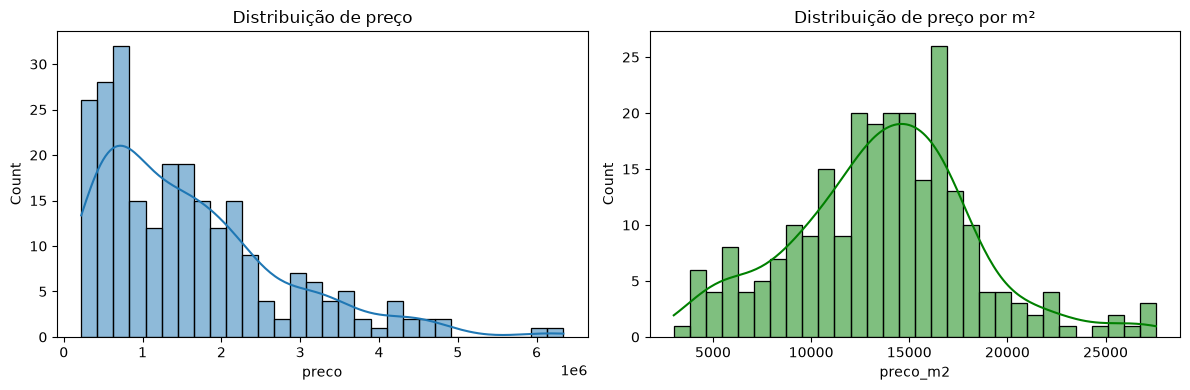

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["preco"], bins=30, kde=True, ax=axes[0])   # kde = curva suave da densidade
axes[0].set_title("Distribuição de preço")
sns.histplot(df["preco_m2"], bins=30, kde=True, ax=axes[1], color="green")      
axes[1].set_title("Distribuição de preço por m²")               # ex.: R$ 1.200/m², R$ 2.500/m², R$ 3.000/m²
plt.tight_layout()                               
plt.savefig("figs/histogramas.png", dpi=150)            # armazena o gráfico em PNG (150 dpi) para o relatório
plt.show()

## Matriz de correlação (`sns.heatmap`)

Correlação de Pearson, de −1 a +1. Ela mede só relação **linear**: por isso o scatter abaixo continua necessário.

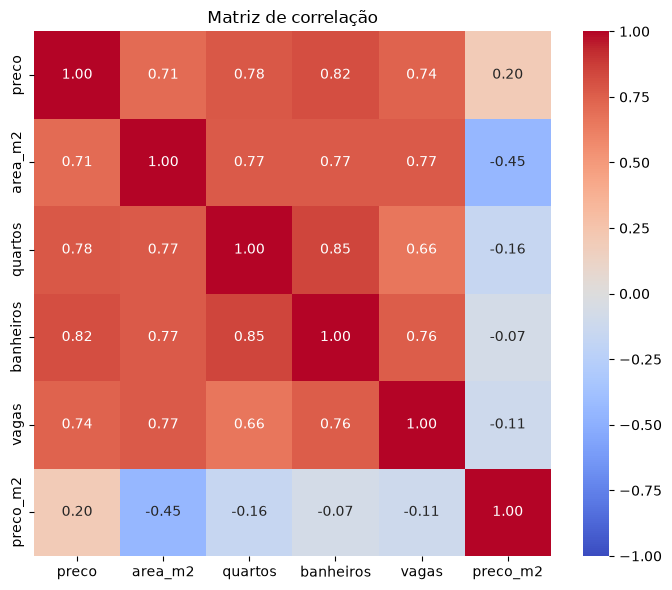

--- Correlação com o preço ---
banheiros    0.82
quartos      0.78
vagas        0.74
area_m2      0.71
preco_m2     0.20
Name: preco, dtype: float64


In [8]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)   # escala fixa em [-1, 1]
plt.title("Matriz de correlação")
plt.tight_layout()
plt.savefig("figs/correlacao.png", dpi=150)
plt.show()

print("--- Correlação com o preço ---")
print(df[numericas].corr()["preco"].drop("preco").sort_values(ascending=False).round(2))

## Scatter `area_m2` × `preco` com reta de tendência

O `regplot` ajusta uma **Regressão Linear Simples** (preço ~ área). A faixa em volta da reta é o intervalo de confiança.

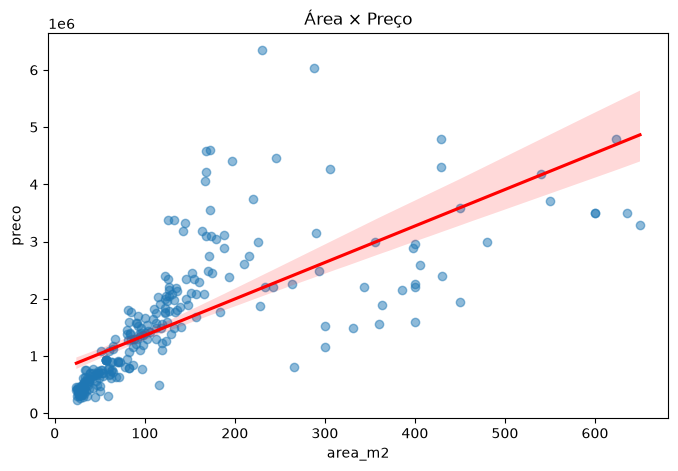

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="area_m2", y="preco", scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}) 
plt.title("Área × Preço")
plt.savefig("figs/scatter_area_preco.png", dpi=150)
plt.show()

## Boxplot de `preco` por `bairro` (top 10)

A caixa vai do Q1 ao Q3, e a linha do meio é a mediana. Caixas mais à direita indicam bairros mais caros; caixas largas, preços muito variados. Aqui há só 6 bairros, então o top 10 mostra todos.

Bairros no boxplot: ['Asa Norte', 'Noroeste', 'Sudoeste', 'Asa Sul', 'Lago Norte', 'Lago Sul']



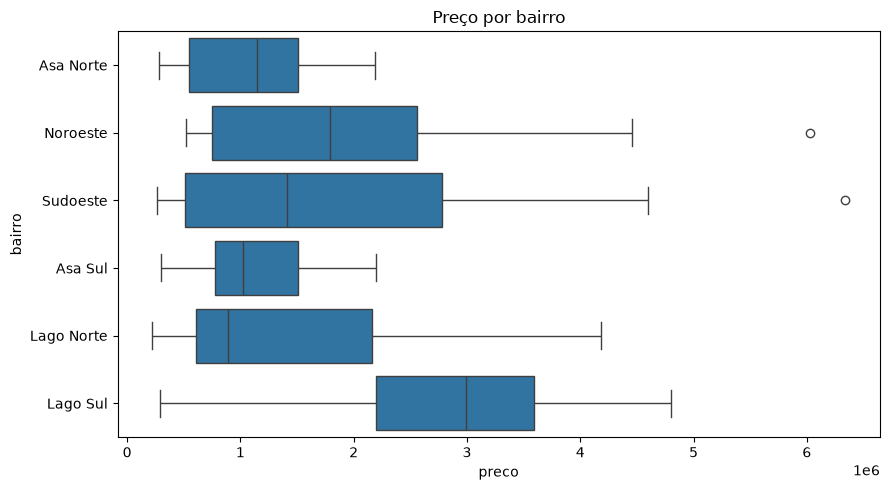

In [10]:
top10 = df["bairro"].value_counts().head(10).index   # os 10 bairros com mais anúncios
print(f"Bairros no boxplot: {list(top10)}\n")

plt.figure(figsize=(9, 5))
sns.boxplot(data=df[df["bairro"].isin(top10)], x="preco", y="bairro", order=top10)
plt.title("Preço por bairro")
plt.tight_layout()
plt.savefig("figs/boxplot_bairros.png", dpi=150)
plt.show()

## Quais variáveis parecem mais correlacionadas com o preço? A relação é linear?

> A relação não é perfeitamente linear: casas (lotes grandes nos Lagos) seguem outra reta que os apartamentos, e a dispersão cresce com a área. Por isso `tipo`, `bairro` e o `log(preco)` entram no modelo.